In [1]:
#We are defining the class of our model
class Simple_Model:
    def __init__(self, num_features, num_iterations=1000):
        self.num_iterations = num_iterations
        #...  # init the weights, don't forget the weight for bias
        self.weights = np.random.uniform(-1, 1, size=num_features+1)

    def apply_threshold(self, x):
        # apply the decision rule here
        return 1 if x > 0 else -1
        

    def predict(self, x):
        # the predi ct function add the bias term, do the weighted sum and call the decision rule (apply_threshold)
        x_with_bias = np.insert(x, 0, 1)
        z = np.dot(self.weights, x_with_bias)
        return self.apply_threshold(z)

    def train(self, X, y):
        # the train function will apply the weight update rule for the misclassified examples for num_iterations times
        for _ in range(self.num_iterations):
            #choose one sample (hint: look at np.random.choice() and range() functions
            sample_id = np.random.randint(len(X))
            prediction = self.predict(X[sample_id])
            if(prediction!=y[sample_id]): # adapt your code here, you may not be using sample_id
                x_with_bias = np.insert(X[sample_id], 0, 1)
                self.weights += y[sample_id] * x_with_bias

In [2]:
#This function plot_decision_boundary takes weights, bias, and X and y ranges as input. 
#It calculates points along the decision boundary using the formula for a line (w1x1 + w2x2 + b = 0) and then
#plots the decision boundary using Matplotlib. You can call this function with different weight and bias values to 
#visualize different decision boundaries.
def plot_decision_boundary(weights, bias, X, y):

    plt.figure(figsize=(5, 4))

    # plotting the examples (hint: check what you did for the 2D plot 
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class +1')
    plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1')

    # Generate points along the decision boundary
    x1 = np.linspace(min(X[:, 0]), max(X[:, 0]), len(X))

    # find the formula for the line w1x1 + w2x2 + b = 0
    x2 = -(bias + weights[0] * x1) / weights[1]

    # Plot the decision boundary
    plt.plot(x1, x2, color='black', label='Decision Boundary')
    
    plt.title('Linearly Separable Dataset')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random

from sklearn.datasets import make_classification

# to display plots in Jupyter notebook
%matplotlib widget

#We will do some 3D plotting
from mpl_toolkits.mplot3d import Axes3D

In [4]:
# Generate a linearly separable dataset with two classes and two features
n_samples = 100
X, y = make_classification(n_samples=n_samples, n_features=2, n_classes=2, n_clusters_per_class=1, n_redundant=0, n_informative=1, random_state=42)

#Using label classes as -1 and 1 to work with our current algorithm
y[y==0] = -1

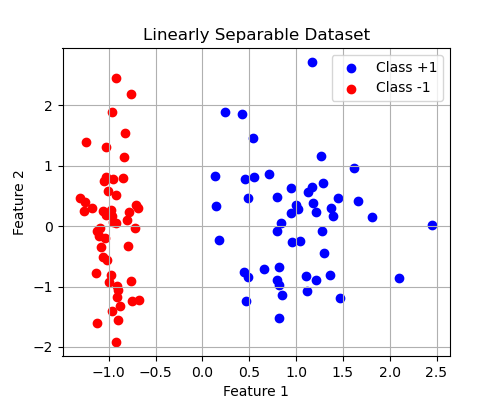

In [5]:
# Plot the dataset
plt.figure(figsize=(5, 4))

#you can plot the examples and have different colors for the different classes using plt.scatter() like the examples in the lecture
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class +1')
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class -1')
plt.title('Linearly Separable Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

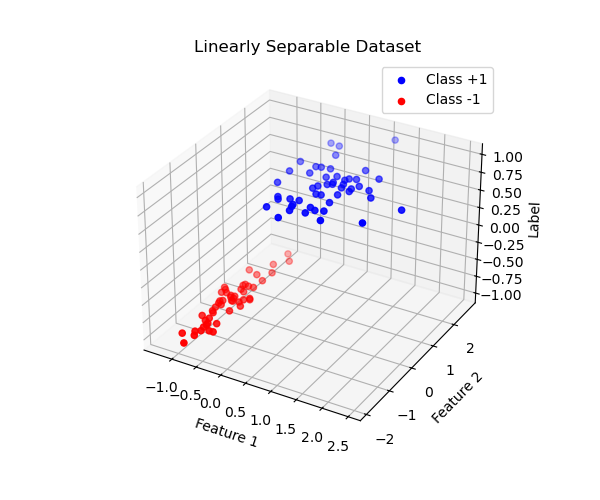

In [6]:
# Plot the dataset in 3D
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')

# Scatter points with label as z-coordinate
ax.scatter(X[y == 1, 0], X[y == 1, 1], y[y == 1], color='blue', label='Class +1')
ax.scatter(X[y == -1, 0], X[y == -1, 1], y[y == -1], color='red', label='Class -1')

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Label')
plt.title('Linearly Separable Dataset')
plt.legend()

# Enable interactive mode for rotation
plt.ion()
plt.show()

In [7]:
simple_model = Simple_Model(num_features=2, num_iterations=1000)

#call the train function
simple_model.train(X, y)
print("Training complete. Final weights (bias, w1, w2):", simple_model.weights)

Training complete. Final weights (bias, w1, w2): [ 0.28066977  1.60978312 -0.22082508]


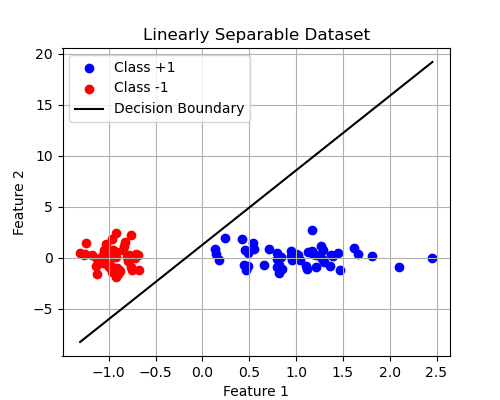

In [8]:
#simple_model.weights will have the weights in norm vector. This is of the form [w0,w1,w2], w0 is bias parameter.
weights = simple_model.weights[1:]
bias = simple_model.weights[0]

plot_decision_boundary(weights, bias, X, y)